# Track B Architecture Comparison

这个 notebook 用来做 Track B 的统一实验台。现在已经接入 `encoder_only`、`cls-token transformer`、`1-D Conv + Transformer`、`TCN + Transformer`、`MAE-style encoder-decoder transformer`、`pure_rnn`、`rnn_lstm_hybrid`、`RNN Autoencoder`、`LSTM Autoencoder`、`Transformer Autoencoder`、`VAE`、`KMeans`、`PCA + KMeans`。

后面如果你还要继续加别的架构，只要沿用同样的 runner 接口注册进去，这个 notebook 就可以继续作为统一对比面板。


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))

LOCAL_MODULE_NAMES = [
    "encoder_only_transformer",
    "rnn_baselines",
    "experiment_utils",
    "advanced_transformer_variants",
    "paper_transformer_variants",
    "autoencoder_and_clustering_baselines",
    "experiment_presets",
    "cluster_action_backtest",
    "rl_backtest_agent",
    "experiment_cache",
]

for module_name in LOCAL_MODULE_NAMES:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])
    else:
        importlib.import_module(module_name)

from cluster_action_backtest import (
    ActionBacktestConfig,
    build_default_action_library,
    build_hmm_baseline_experiment_result,
    build_model_ranking_tables,
    evaluate_model_cluster_actions,
    evaluate_random_choice_baseline,
    load_tradable_returns,
)
from encoder_only_transformer import HMMLEARN_AVAILABLE, compare_experiment_summaries
from experiment_cache import DEFAULT_MODELS_DIR, run_experiment_with_cache
from experiment_presets import (
    build_architecture_runners,
    build_default_clustering_config,
    build_default_data_config,
    build_market_tuple_data_config,
    build_default_experiment_setups,
    build_default_hmm_config,
    build_default_model_config,
    build_default_training_config,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


## Single Experiment Configuration

先在这里配置一个单独实验。当前支持的架构已经不止 RNN / Transformer 基线，而是统一通过 `ARCHITECTURE_RUNNERS` 注册。你只需要切换 `architecture_name`，下面的数据构造、训练、聚类和评估流程都会复用。


In [2]:
ARCHITECTURE_RUNNERS = build_architecture_runners()
TARGET_CLUSTER_COUNT = 4
DATA_DIR = NOTEBOOK_DIR.parent / "data"
MODELS_DIR = NOTEBOOK_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

architecture_name = "encoder_only"
experiment_name = f"{architecture_name}_baseline"

BACKTEST_ASSETS = ("SPY", "TLT", "GLD")
BACKTEST_VALIDATION_RATIO = 0.20
BACKTEST_TEST_RATIO = 0.10
BACKTEST_OBJECTIVE = "sharpe"
ALLOW_ACTION_REUSE = False
INCLUDE_RANDOM_CHOICE_BASELINE = True
RANDOM_CHOICE_SEED = 42
INCLUDE_HMM_BASELINE = True
RL_REUSE_SAVED_POLICIES = False

data_config = (
    build_market_tuple_data_config(DATA_DIR)
    if architecture_name == "encoder_only_market_tuples"
    else build_default_data_config(DATA_DIR)
)
model_config = build_default_model_config(architecture_name)
training_config = build_default_training_config(architecture_name)
clustering_config = build_default_clustering_config(target_cluster_count=TARGET_CLUSTER_COUNT)
hmm_config = build_default_hmm_config(
    hmm_enabled=HMMLEARN_AVAILABLE,
    target_cluster_count=TARGET_CLUSTER_COUNT,
)

print("architecture_name       =", architecture_name)
print("experiment_name         =", experiment_name)
print("hmm_enabled             =", hmm_config.enabled)
print("target_clusters         =", TARGET_CLUSTER_COUNT)
print("backtest_assets         =", BACKTEST_ASSETS)
print("backtest_validation     =", BACKTEST_VALIDATION_RATIO)
print("backtest_test           =", BACKTEST_TEST_RATIO)
print("backtest_objective      =", BACKTEST_OBJECTIVE)
print("allow_action_reuse      =", ALLOW_ACTION_REUSE)
print("include_random_choice   =", INCLUDE_RANDOM_CHOICE_BASELINE)
print("random_choice_seed      =", RANDOM_CHOICE_SEED)
print("include_hmm_baseline    =", INCLUDE_HMM_BASELINE)
print("rl_reuse_saved_policies =", RL_REUSE_SAVED_POLICIES)
print("models_dir             =", MODELS_DIR)


architecture_name       = encoder_only
experiment_name         = encoder_only_baseline
hmm_enabled             = True
target_clusters         = 4
backtest_assets         = ('SPY', 'TLT', 'GLD')
backtest_validation     = 0.15
backtest_test           = 0.15
backtest_objective      = sharpe
allow_action_reuse      = False
include_random_choice   = True
random_choice_seed      = 42
include_hmm_baseline    = True


## Batch Comparison Template

这里放整组实验设置。当前默认已经把所有 Track B 候选架构和经典聚类 baseline 都列进来了，你可以直接整批跑，也可以删减成自己这轮想比较的子集。


In [3]:
experiment_setups = build_default_experiment_setups(
    data_dir=DATA_DIR,
    hmm_enabled=HMMLEARN_AVAILABLE,
    target_cluster_count=TARGET_CLUSTER_COUNT,
)

display(pd.DataFrame({
    "name": [setup["name"] for setup in experiment_setups],
    "architecture": [setup["architecture"] for setup in experiment_setups],
    "epochs": [setup["training_config"].num_epochs for setup in experiment_setups],
}))


,name,architecture,epochs
0,encoder_only,encoder_only,80
1,encoder_only_market_tuples,encoder_only_market_tuples,80
2,cls_token_transformer,cls_token_transformer,80
3,conv_transformer,conv_transformer,60
4,tcn_transformer,tcn_transformer,60
5,mae_transformer,mae_transformer,60
6,pure_rnn,pure_rnn,80
7,rnn_lstm_hybrid,rnn_lstm_hybrid,80
8,rnn_autoencoder,rnn_autoencoder,60
9,lstm_autoencoder,lstm_autoencoder,60


In [4]:
batch_results = []

for setup in experiment_setups:
    runner = ARCHITECTURE_RUNNERS[setup["architecture"]]
    result = run_experiment_with_cache(
        runner=runner,
        experiment_name=setup["name"],
        data_config=setup["data_config"],
        model_config=setup["model_config"],
        training_config=setup["training_config"],
        clustering_config=setup["clustering_config"],
        hmm_config=setup["hmm_config"],
        models_dir=MODELS_DIR,
        verbose=True,
    )
    batch_results.append(result)

comparison_df = compare_experiment_summaries(batch_results)
display(comparison_df)


[encoder_only] epoch=1/80 train_loss=0.808119 val_loss=0.662626
[encoder_only] epoch=2/80 train_loss=0.701502 val_loss=0.651991
[encoder_only] epoch=3/80 train_loss=0.681039 val_loss=0.647098
[encoder_only] epoch=4/80 train_loss=0.655463 val_loss=0.645267
[encoder_only] epoch=5/80 train_loss=0.640112 val_loss=0.638975
[encoder_only] epoch=6/80 train_loss=0.624646 val_loss=0.640845
[encoder_only] epoch=7/80 train_loss=0.608745 val_loss=0.630970
[encoder_only] epoch=8/80 train_loss=0.603958 val_loss=0.637018
[encoder_only] epoch=9/80 train_loss=0.605365 val_loss=0.627724
[encoder_only] epoch=10/80 train_loss=0.592211 val_loss=0.626088
[encoder_only] epoch=11/80 train_loss=0.588861 val_loss=0.629042
[encoder_only] epoch=12/80 train_loss=0.588758 val_loss=0.621129
[encoder_only] epoch=13/80 train_loss=0.575434 val_loss=0.622921
[encoder_only] epoch=14/80 train_loss=0.571452 val_loss=0.631472
[encoder_only] epoch=15/80 train_loss=0.572925 val_loss=0.623056
[encoder_only] epoch=16/80 train_l

,experiment_name,architecture,input_dim,window_size,n_sequence_rows,n_windows,used_sequence_features,skipped_sequence_features,best_epoch,best_val_loss,target_cluster_count,silhouette,ari_vs_hmm,nmi_vs_hmm
0,encoder_only_market_tuples,encoder_only_market_tuples,35,60,2835,2776,"GLD_close, GLD_high, GLD_low, GLD_open, GLD_lo...",,23,0.997214,4,0.495770,0.106074,0.168125
1,transformer_autoencoder,transformer_autoencoder,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,31,0.254028,4,0.185025,0.094576,0.163846
2,conv_transformer,conv_transformer,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,15,0.640408,4,0.282467,0.058565,0.129532
3,encoder_only,encoder_only,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,12,0.621129,4,0.215130,0.049603,0.106106
4,cls_token_transformer,encoder_only,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,17,0.621987,4,0.242331,0.044732,0.087533
5,rnn_lstm_hybrid,rnn_lstm_hybrid,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,6,0.640009,4,0.175749,0.029005,0.081020
6,tcn_transformer,tcn_transformer,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,9,0.649220,4,0.171543,0.027821,0.078873
7,lstm_autoencoder,lstm_autoencoder,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,8,0.900436,4,0.223257,0.020803,0.063812
8,rnn_autoencoder,rnn_autoencoder,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,7,0.902626,4,0.223136,0.018740,0.055529
9,mae_transformer,mae_transformer,8,60,2834,2775,"SPY_ret, TLT_ret, GLD_ret, UUP_ret, HYG_ret, L...",,3,0.888564,4,0.173125,0.017917,0.036819


## Cluster-to-Action Ranking

这一段直接把每个模型的 `cluster` 当作离散状态，不再人为命名成 `Stress / Risk-On`。同时会把 `HMM baseline` 一起放进同一张 leaderboard。

流程是：

1. 用统一的 `train / validation / test` 时间切分。
2. 在验证集上遍历 `cluster -> action` 映射，选出最优 mapping。
3. 固定 mapping 后，在测试集上比较所有模型的 out-of-sample 表现。


In [5]:
backtest_config = ActionBacktestConfig(
    tradable_assets=BACKTEST_ASSETS,
    validation_ratio=BACKTEST_VALIDATION_RATIO,
    test_ratio=BACKTEST_TEST_RATIO,
    objective=BACKTEST_OBJECTIVE,
    allow_action_reuse=ALLOW_ACTION_REUSE,
)

action_library = build_default_action_library(
    n_actions=TARGET_CLUSTER_COUNT,
    tradable_assets=backtest_config.tradable_assets,
)
action_library_df = pd.DataFrame(action_library).T
action_library_df.index.name = "action"

asset_returns = load_tradable_returns(
    data_config=batch_results[0]["data_config"],
    tradable_assets=backtest_config.tradable_assets,
)

ranking_experiment_results = list(batch_results)
evaluation_results = []

if INCLUDE_RANDOM_CHOICE_BASELINE:
    evaluation_results.append(
        evaluate_random_choice_baseline(
            data_config=batch_results[0]["data_config"],
            asset_returns=asset_returns,
            action_library=action_library,
            config=backtest_config,
            random_state=RANDOM_CHOICE_SEED,
        )
    )

if INCLUDE_HMM_BASELINE and HMMLEARN_AVAILABLE:
    hmm_baseline_result = build_hmm_baseline_experiment_result(
        data_config=batch_results[0]["data_config"],
        target_cluster_count=TARGET_CLUSTER_COUNT,
        random_state=42,
    )
    if hmm_baseline_result is not None:
        ranking_experiment_results = [hmm_baseline_result] + ranking_experiment_results

evaluation_results.extend([
    evaluate_model_cluster_actions(
        experiment_result=result,
        asset_returns=asset_returns,
        action_library=action_library,
        config=backtest_config,
    )
    for result in ranking_experiment_results
])

validation_ranking_df, test_ranking_df, combined_ranking_df = build_model_ranking_tables(
    evaluation_results=evaluation_results,
    objective=backtest_config.objective,
)

split_summary_df = evaluation_results[0]["split_summary"]

display(split_summary_df)
display(action_library_df)
display(validation_ranking_df[[
    "validation_rank",
    "experiment_name",
    "architecture",
    f"validation_{backtest_config.objective}",
    "validation_annual_return",
    "validation_max_drawdown",
    "best_mapping",
]])
display(test_ranking_df[[
    "test_rank",
    "experiment_name",
    "architecture",
    f"test_{backtest_config.objective}",
    "test_annual_return",
    "test_max_drawdown",
    "best_mapping",
]])


,split,n_windows,start_date,end_date
0,train,1943,2015-03-31,2022-12-14
1,validation,416,2022-12-15,2024-08-13
2,test,416,2024-08-14,2026-04-13


,SPY,TLT,GLD
action,,,
defensive,0.2,0.5,0.3
cautious,0.3,0.4,0.3
rebound,0.5,0.3,0.2
aggressive,0.7,0.2,0.1


,validation_rank,experiment_name,architecture,validation_sharpe,validation_annual_return,validation_max_drawdown,best_mapping
0,1,hmm_baseline,hmm_baseline,1.564482,0.179864,-0.099832,0->defensive; 1->cautious; 2->rebound; 3->aggr...
1,2,encoder_only,encoder_only,1.517504,0.179557,-0.102916,0->cautious; 1->aggressive; 2->rebound; 3->def...
2,3,cls_token_transformer,encoder_only,1.493061,0.174532,-0.095082,0->defensive; 1->cautious; 2->rebound; 3->aggr...
3,4,tcn_transformer,tcn_transformer,1.456461,0.171714,-0.090880,0->cautious; 1->aggressive; 2->rebound; 3->def...
4,5,conv_transformer,conv_transformer,1.449559,0.169541,-0.096281,0->aggressive; 1->defensive; 2->rebound; 3->ca...
5,6,encoder_only_market_tuples,encoder_only_market_tuples,1.419349,0.170793,-0.099832,0->defensive; 1->aggressive; 2->cautious; 3->r...
6,7,lstm_autoencoder,lstm_autoencoder,1.348303,0.162204,-0.109070,0->aggressive; 1->cautious; 2->defensive; 3->r...
7,8,pure_rnn,pure_rnn,1.273778,0.156389,-0.114453,0->rebound; 1->aggressive; 2->defensive; 3->ca...
8,9,rnn_lstm_hybrid,rnn_lstm_hybrid,1.180728,0.141714,-0.109800,0->aggressive; 1->rebound; 2->defensive; 3->ca...
9,10,transformer_autoencoder,transformer_autoencoder,1.142952,0.139891,-0.101392,0->cautious; 1->rebound; 2->aggressive; 3->def...


,test_rank,experiment_name,architecture,test_sharpe,test_annual_return,test_max_drawdown,best_mapping
0,1,pure_rnn,pure_rnn,1.579910,0.191548,-0.089011,0->rebound; 1->aggressive; 2->defensive; 3->ca...
1,2,cls_token_transformer,encoder_only,1.468505,0.170328,-0.081990,0->defensive; 1->cautious; 2->rebound; 3->aggr...
2,3,encoder_only,encoder_only,1.422674,0.172539,-0.089011,0->cautious; 1->aggressive; 2->rebound; 3->def...
3,4,tcn_transformer,tcn_transformer,1.295037,0.168945,-0.088786,0->cautious; 1->aggressive; 2->rebound; 3->def...
4,5,lstm_autoencoder,lstm_autoencoder,1.216288,0.153844,-0.093872,0->aggressive; 1->cautious; 2->defensive; 3->r...
5,6,rnn_lstm_hybrid,rnn_lstm_hybrid,1.088262,0.147243,-0.121271,0->aggressive; 1->rebound; 2->defensive; 3->ca...
6,7,encoder_only_market_tuples,encoder_only_market_tuples,1.082397,0.160654,-0.131087,0->defensive; 1->aggressive; 2->cautious; 3->r...
7,8,hmm_baseline,hmm_baseline,0.990308,0.131271,-0.089827,0->defensive; 1->cautious; 2->rebound; 3->aggr...
8,9,mae_transformer,mae_transformer,0.972617,0.144740,-0.109862,0->rebound; 1->defensive; 2->aggressive; 3->ca...
9,10,rnn_autoencoder,rnn_autoencoder,0.834606,0.113464,-0.092674,0->rebound; 1->defensive; 2->cautious; 3->aggr...


## PCA Scatter of HMM and Model Classifications

这一段把 `HMM` 和当前 `batch_results` 里的所有模型分类结果都压到二维空间里画散点图：

- `HMM` 子图：对 HMM 参考特征做 PCA，按 `hmm_regime` 上色。
- 模型子图：对每个模型学到的 `embedding` 做 PCA，按 `cluster` 上色。

子图数量会随着你注册进来的架构动态扩展。这样你可以直接看出不同方法的分群形状、簇间分离程度，以及它们和 HMM 的视觉差异。


Common aligned windows for visualization: 2775


C:\Users\32881\AppData\Local\Temp\ipykernel_25912\4136601918.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
C:\Users\32881\AppData\Local\Temp\ipykernel_25912\4136601918.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
C:\Users\32881\AppData\Local\Temp\ipykernel_25912\4136601918.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap

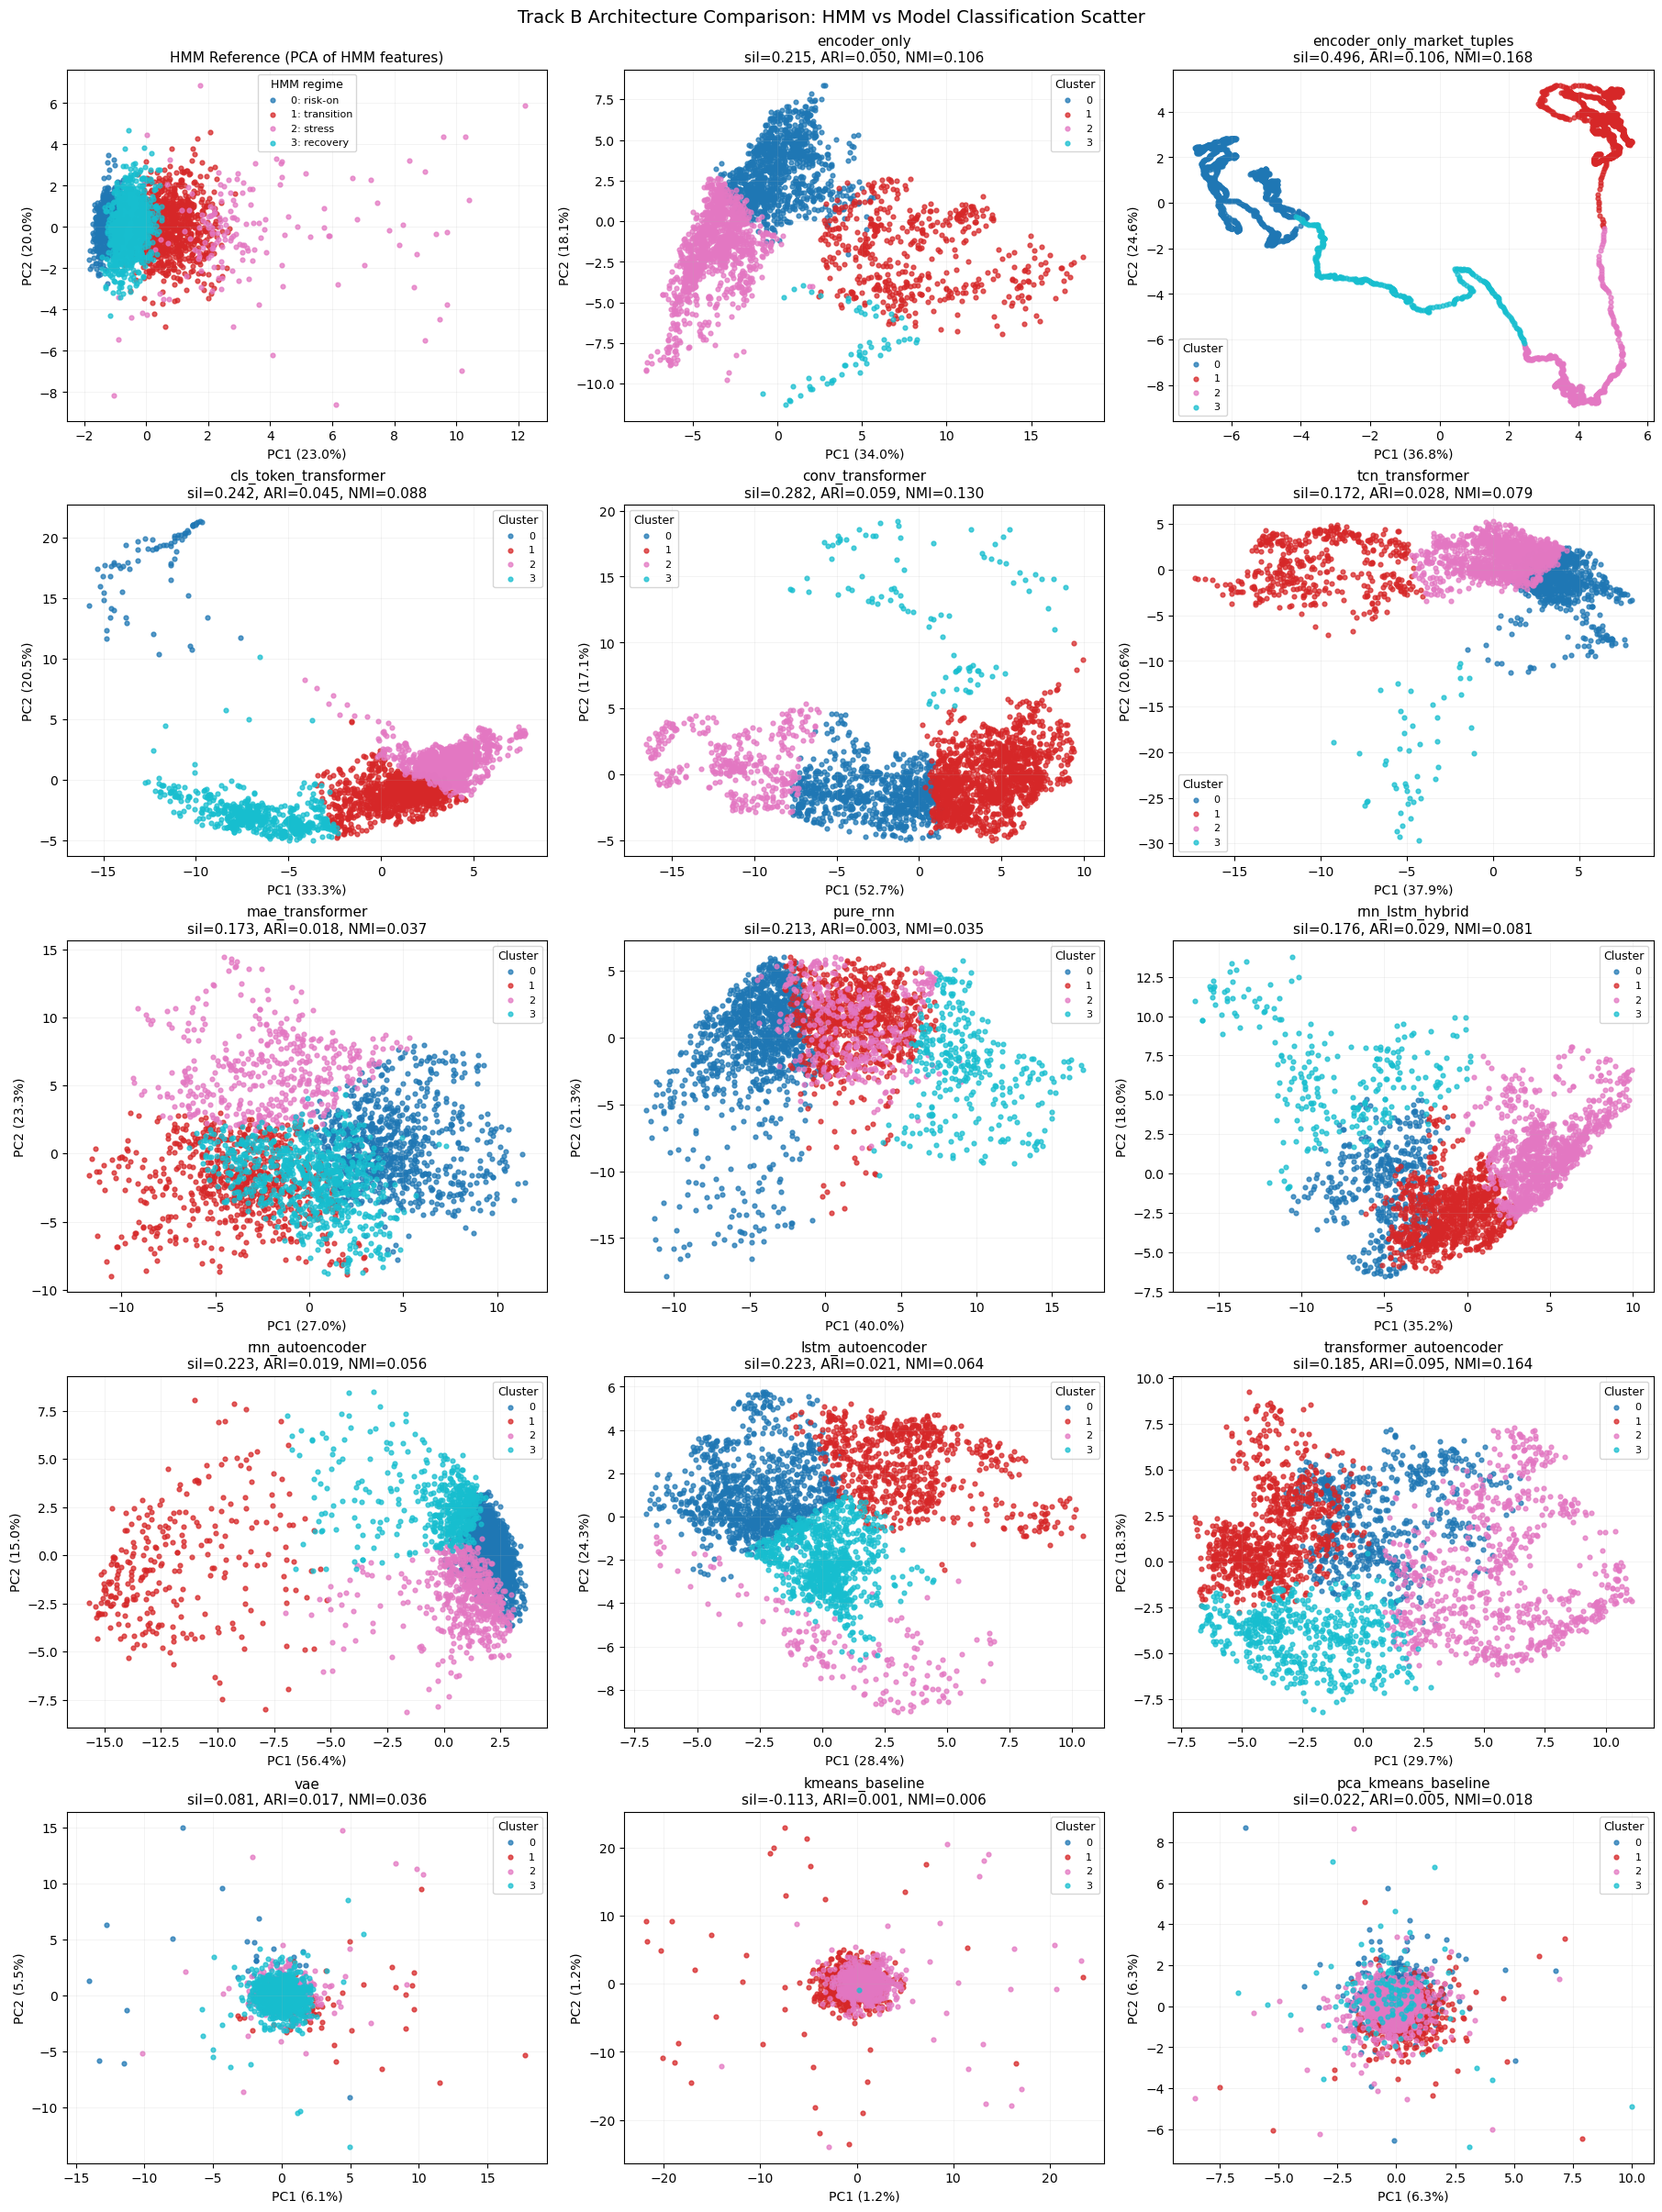

In [6]:
hmm_source_result = next((result for result in batch_results if result.get("hmm_results") is not None), None)
if hmm_source_result is None:
    raise ValueError("No HMM reference found in batch_results. Enable HMM comparison in at least one experiment.")

common_dates = None
for result in batch_results:
    result_dates = pd.Index(result["window_end_dates"], name="Date")
    common_dates = result_dates if common_dates is None else common_dates.intersection(result_dates)

hmm_reference = hmm_source_result["hmm_results"]["hmm_reference"].copy()
common_dates = common_dates.intersection(hmm_reference.index)
common_dates = common_dates.sort_values()

if len(common_dates) == 0:
    raise ValueError("No overlapping dates found between model windows and HMM reference.")

print(f"Common aligned windows for visualization: {len(common_dates)}")


def compute_pca_projection(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    scaled = StandardScaler().fit_transform(matrix)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(scaled)
    return coords, pca.explained_variance_ratio_


def scatter_by_label(ax, coords: np.ndarray, labels: pd.Series, title: str, explained_ratio: np.ndarray, legend_title: str):
    label_series = labels.astype(str)
    unique_labels = sorted(label_series.unique())
    cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))

    for idx, label in enumerate(unique_labels):
        mask = (label_series == label).to_numpy()
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=12,
            alpha=0.75,
            color=cmap(idx),
            label=label,
        )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"PC1 ({explained_ratio[0]:.1%})")
    ax.set_ylabel(f"PC2 ({explained_ratio[1]:.1%})")
    ax.grid(alpha=0.2, linewidth=0.5)
    ax.legend(title=legend_title, fontsize=8, title_fontsize=9, loc="best")


n_panels = len(batch_results) + 1
n_cols = 3
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.8 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

numeric_hmm_columns = [
    column
    for column in hmm_reference.columns
    if column not in {"hmm_state", "hmm_regime"} and pd.api.types.is_numeric_dtype(hmm_reference[column])
]
hmm_view = hmm_reference.loc[common_dates, numeric_hmm_columns]
hmm_coords, hmm_ratio = compute_pca_projection(hmm_view.to_numpy())
hmm_labels = hmm_reference.loc[common_dates].apply(
    lambda row: f"{int(row['hmm_state'])}: {row['hmm_regime']}",
    axis=1,
)
scatter_by_label(
    axes[0],
    hmm_coords,
    hmm_labels,
    title="HMM Reference (PCA of HMM features)",
    explained_ratio=hmm_ratio,
    legend_title="HMM regime",
)

for plot_idx, result in enumerate(batch_results, start=1):
    result_dates = pd.Index(result["window_end_dates"], name="Date")
    positions = result_dates.get_indexer(common_dates)
    if np.any(positions < 0):
        raise ValueError(f"{result['experiment_name']} is missing some common_dates alignment points.")

    embeddings = result["embeddings"][positions]
    labels = pd.Series(result["cluster_labels"][positions], index=common_dates, name="cluster")
    coords, explained_ratio = compute_pca_projection(embeddings)
    summary = result["summary"]
    title = (
        f"{summary['experiment_name']}\n"
        f"sil={summary['silhouette']:.3f}, ARI={summary['ari_vs_hmm']:.3f}, NMI={summary['nmi_vs_hmm']:.3f}"
    )
    scatter_by_label(
        axes[plot_idx],
        coords,
        labels,
        title=title,
        explained_ratio=explained_ratio,
        legend_title="Cluster",
    )

for ax in axes[n_panels:]:
    ax.axis("off")

plt.suptitle("Track B Architecture Comparison: HMM vs Model Classification Scatter", fontsize=14)
plt.show()


## PCA of Raw Input Windows Colored by Each Classification

这一段不再使用模型学到的 embedding，而是直接对 **原始输入窗口** 做 PCA：

- 先把每个 `60 x feature_dim` 窗口展平成一个向量，再压到二维。
- 然后分别按 `HMM` 和当前所有模型的分类结果上色。

这样你看到的是 **同一份原始数据空间** 里，不同分类器到底是怎么切簇的，而且子图数量会自动随着架构数量扩展。


C:\Users\32881\AppData\Local\Temp\ipykernel_25912\4136601918.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
C:\Users\32881\AppData\Local\Temp\ipykernel_25912\4136601918.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
C:\Users\32881\AppData\Local\Temp\ipykernel_25912\4136601918.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap

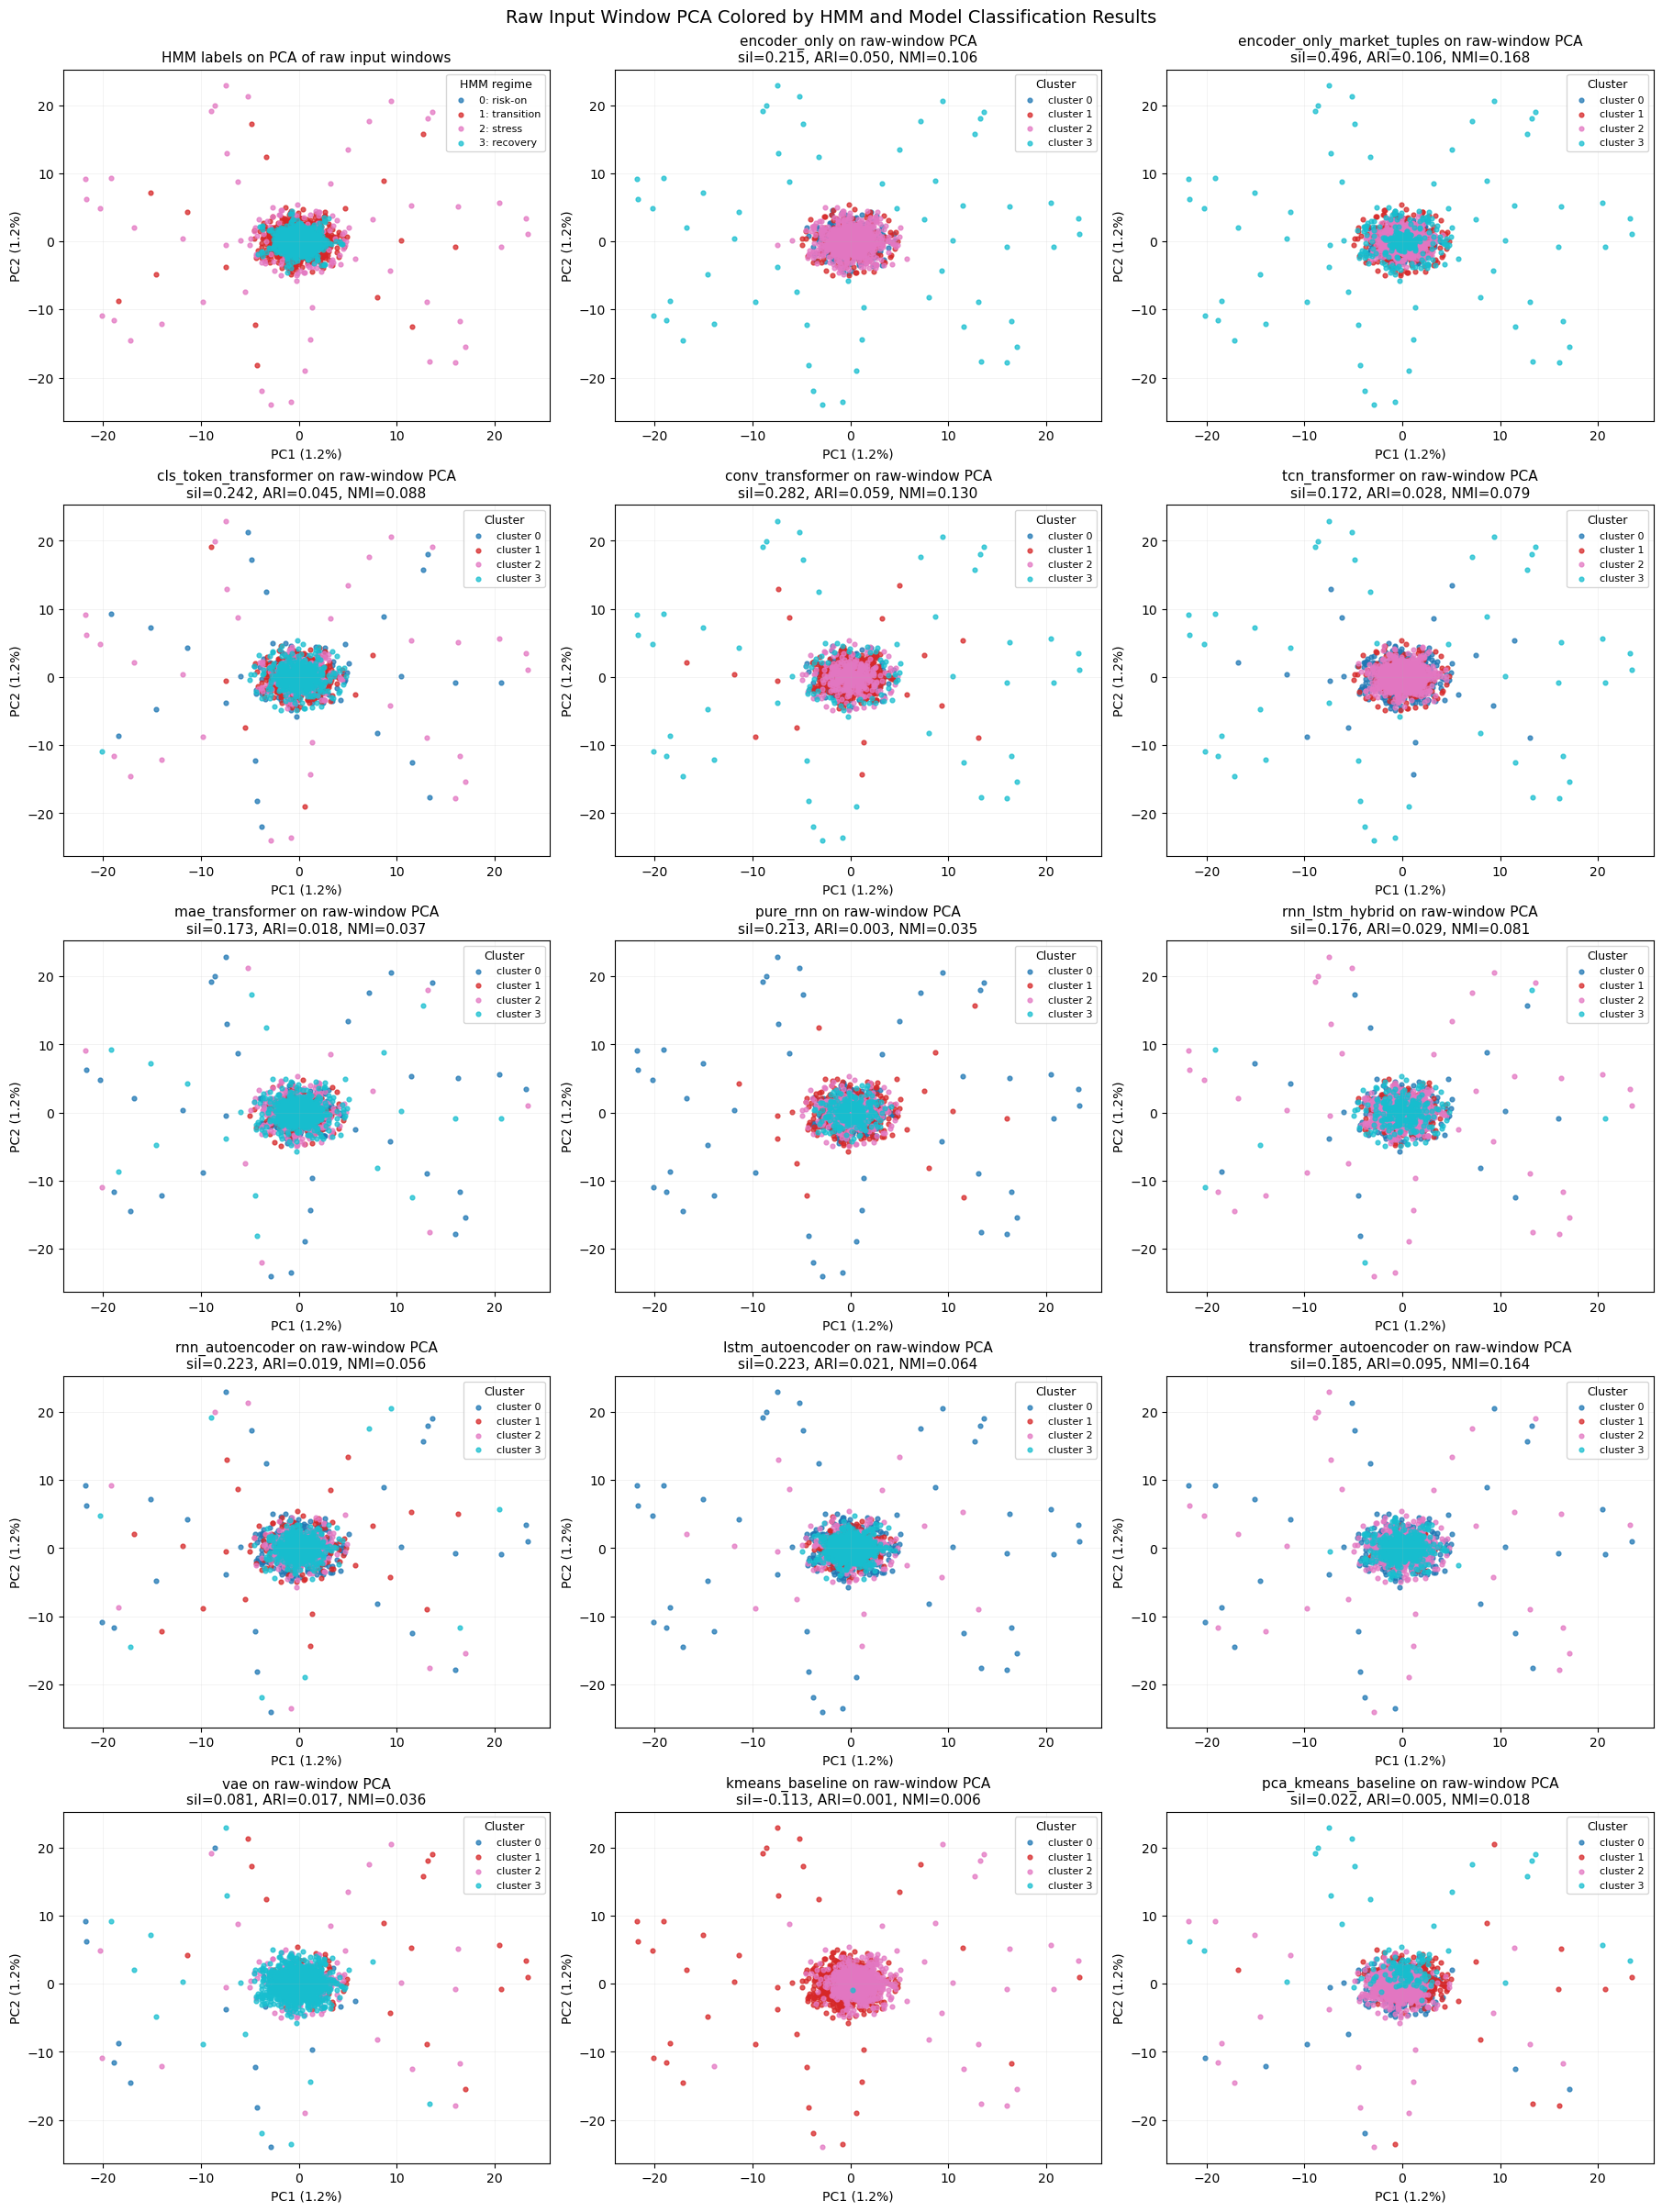

In [7]:
hmm_source_result = next((result for result in batch_results if result.get("hmm_results") is not None), None)
if hmm_source_result is None:
    raise ValueError("No HMM reference found in batch_results. Enable HMM comparison in at least one experiment.")

common_dates_raw = None
for result in batch_results:
    result_dates = pd.Index(result["window_end_dates"], name="Date")
    common_dates_raw = result_dates if common_dates_raw is None else common_dates_raw.intersection(result_dates)

hmm_reference_raw = hmm_source_result["hmm_results"]["hmm_reference"].copy()
common_dates_raw = common_dates_raw.intersection(hmm_reference_raw.index)
common_dates_raw = common_dates_raw.sort_values()

if len(common_dates_raw) == 0:
    raise ValueError("No overlapping dates found between model windows and HMM reference.")

raw_source_result = batch_results[0]
raw_result_dates = pd.Index(raw_source_result["window_end_dates"], name="Date")
raw_positions = raw_result_dates.get_indexer(common_dates_raw)
if np.any(raw_positions < 0):
    raise ValueError("The chosen raw_source_result is missing some common_dates alignment points.")

raw_windows = raw_source_result["windows"][raw_positions]
raw_flattened = raw_windows.reshape(len(raw_windows), -1)
raw_coords, raw_ratio = compute_pca_projection(raw_flattened)

n_panels_raw = len(batch_results) + 1
n_cols_raw = 3
n_rows_raw = int(np.ceil(n_panels_raw / n_cols_raw))
fig, axes = plt.subplots(n_rows_raw, n_cols_raw, figsize=(6 * n_cols_raw, 4.8 * n_rows_raw), constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

hmm_labels_raw = hmm_reference_raw.loc[common_dates_raw].apply(
    lambda row: f"{int(row['hmm_state'])}: {row['hmm_regime']}",
    axis=1,
)
scatter_by_label(
    axes[0],
    raw_coords,
    hmm_labels_raw,
    title="HMM labels on PCA of raw input windows",
    explained_ratio=raw_ratio,
    legend_title="HMM regime",
)

for plot_idx, result in enumerate(batch_results, start=1):
    result_dates = pd.Index(result["window_end_dates"], name="Date")
    positions = result_dates.get_indexer(common_dates_raw)
    if np.any(positions < 0):
        raise ValueError(f"{result['experiment_name']} is missing some common_dates alignment points.")

    labels = pd.Series(result["cluster_labels"][positions], index=common_dates_raw, name="cluster").map(
        lambda value: f"cluster {int(value)}"
    )
    summary = result["summary"]
    title = (
        f"{summary['experiment_name']} on raw-window PCA\n"
        f"sil={summary['silhouette']:.3f}, ARI={summary['ari_vs_hmm']:.3f}, NMI={summary['nmi_vs_hmm']:.3f}"
    )
    scatter_by_label(
        axes[plot_idx],
        raw_coords,
        labels,
        title=title,
        explained_ratio=raw_ratio,
        legend_title="Cluster",
    )

for ax in axes[n_panels_raw:]:
    ax.axis("off")

plt.suptitle("Raw Input Window PCA Colored by HMM and Model Classification Results", fontsize=14)
plt.show()


## Full Testbench Export

这个 block 会直接调用 `run_cluster_action_rankings.py` 跑完整的 ranking / backtest / 可视化流程，
并把结果统一输出到 `Final_Project/track_b/results/cluster_action_rankings_k{TARGET_CLUSTER_COUNT}`。

运行完成后会：

- 打印脚本输出日志
- 显示切分结果与验证集/测试集排名
- 显示生成的 PNG / GIF 文件清单


In [8]:
import subprocess

FULL_TESTBENCH_OUTPUT_DIR = NOTEBOOK_DIR / "results" / f"cluster_action_rankings_k{TARGET_CLUSTER_COUNT}"
FULL_TESTBENCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

full_testbench_command = [
    sys.executable,
    str(NOTEBOOK_DIR / "run_cluster_action_rankings.py"),
    "--cluster-count",
    str(TARGET_CLUSTER_COUNT),
    "--device",
    str(training_config.device),
    "--validation-ratio",
    str(BACKTEST_VALIDATION_RATIO),
    "--test-ratio",
    str(BACKTEST_TEST_RATIO),
    "--objective",
    str(BACKTEST_OBJECTIVE),
    "--output-dir",
    str(FULL_TESTBENCH_OUTPUT_DIR),
    "--models-dir",
    str(MODELS_DIR),
    "--assets",
    *BACKTEST_ASSETS,
]

if ALLOW_ACTION_REUSE:
    full_testbench_command.append("--allow-action-reuse")
else:
    full_testbench_command.append("--no-action-reuse")

if INCLUDE_RANDOM_CHOICE_BASELINE:
    full_testbench_command.append("--include-random-choice-baseline")
    full_testbench_command.extend(["--random-choice-seed", str(RANDOM_CHOICE_SEED)])
else:
    full_testbench_command.append("--skip-random-choice-baseline")

if INCLUDE_HMM_BASELINE:
    full_testbench_command.append("--include-hmm-baseline")
else:
    full_testbench_command.append("--skip-hmm-baseline")

full_testbench_result = subprocess.run(
    full_testbench_command,
    cwd=NOTEBOOK_DIR,
    capture_output=True,
    text=True,
    check=True,
)

print(full_testbench_result.stdout)
if full_testbench_result.stderr.strip():
    print("[stderr]")
    print(full_testbench_result.stderr)

full_split_summary_df = pd.read_csv(FULL_TESTBENCH_OUTPUT_DIR / "split_summary.csv")
full_validation_ranking_df = pd.read_csv(FULL_TESTBENCH_OUTPUT_DIR / "validation_ranking.csv")
full_test_ranking_df = pd.read_csv(FULL_TESTBENCH_OUTPUT_DIR / "test_ranking.csv")
full_plot_manifest_df = pd.read_csv(FULL_TESTBENCH_OUTPUT_DIR / "plots" / "plot_manifest.csv")

print(f"Saved full testbench results to: {FULL_TESTBENCH_OUTPUT_DIR}")
display(full_split_summary_df)
display(full_validation_ranking_df[[
    "validation_rank",
    "experiment_name",
    "architecture",
    f"validation_{BACKTEST_OBJECTIVE}",
    "validation_annual_return",
    "validation_max_drawdown",
    "best_mapping",
]])
display(full_test_ranking_df[[
    "test_rank",
    "experiment_name",
    "architecture",
    f"test_{BACKTEST_OBJECTIVE}",
    "test_annual_return",
    "test_max_drawdown",
    "best_mapping",
]])
display(full_plot_manifest_df)


Action library:
            SPY  TLT  GLD
action                   
defensive  0.20 0.50 0.30
cautious   0.30 0.40 0.30
rebound    0.50 0.30 0.20
aggressive 0.70 0.20 0.10

Running models:
  - encoder_only: architecture=encoder_only, train_ratio=0.70
  - encoder_only_market_tuples: architecture=encoder_only_market_tuples, train_ratio=0.70
  - cls_token_transformer: architecture=cls_token_transformer, train_ratio=0.70
  - conv_transformer: architecture=conv_transformer, train_ratio=0.70
  - tcn_transformer: architecture=tcn_transformer, train_ratio=0.70
  - mae_transformer: architecture=mae_transformer, train_ratio=0.70
  - pure_rnn: architecture=pure_rnn, train_ratio=0.70
  - rnn_lstm_hybrid: architecture=rnn_lstm_hybrid, train_ratio=0.70
  - rnn_autoencoder: architecture=rnn_autoencoder, train_ratio=0.70
  - lstm_autoencoder: architecture=lstm_autoencoder, train_ratio=0.70
  - transformer_autoencoder: architecture=transformer_autoencoder, train_ratio=0.70
  - vae: architecture=vae, tr

,split,n_windows,start_date,end_date
0,train,1943,2015-03-31,2022-12-14
1,validation,416,2022-12-15,2024-08-13
2,test,416,2024-08-14,2026-04-13


,validation_rank,experiment_name,architecture,validation_sharpe,validation_annual_return,validation_max_drawdown,best_mapping
0,1,hmm_baseline,hmm_baseline,1.564482,0.179864,-0.099832,0->defensive; 1->cautious; 2->rebound; 3->aggr...
1,2,tcn_transformer,tcn_transformer,1.451111,0.171549,-0.092880,0->aggressive; 1->rebound; 2->defensive; 3->ca...
2,3,rnn_lstm_hybrid,rnn_lstm_hybrid,1.448162,0.171390,-0.099832,0->defensive; 1->aggressive; 2->cautious; 3->r...
3,4,encoder_only_market_tuples,encoder_only_market_tuples,1.419349,0.170793,-0.099832,0->defensive; 1->aggressive; 2->cautious; 3->r...
4,5,mae_transformer,mae_transformer,1.419036,0.171020,-0.099422,0->cautious; 1->rebound; 2->aggressive; 3->def...
5,6,conv_transformer,conv_transformer,1.404966,0.161586,-0.099832,0->defensive; 1->aggressive; 2->cautious; 3->r...
6,7,rnn_autoencoder,rnn_autoencoder,1.388643,0.168229,-0.101183,0->defensive; 1->aggressive; 2->cautious; 3->r...
7,8,encoder_only,encoder_only,1.347287,0.158935,-0.101392,0->defensive; 1->aggressive; 2->cautious; 3->r...
8,9,lstm_autoencoder,lstm_autoencoder,1.307379,0.154325,-0.101392,0->defensive; 1->aggressive; 2->rebound; 3->ca...
9,10,transformer_autoencoder,transformer_autoencoder,1.292619,0.158024,-0.106837,0->aggressive; 1->rebound; 2->defensive; 3->ca...


,test_rank,experiment_name,architecture,test_sharpe,test_annual_return,test_max_drawdown,best_mapping
0,1,pure_rnn,pure_rnn,1.847964,0.218419,-0.088159,0->defensive; 1->aggressive; 2->rebound; 3->ca...
1,2,mae_transformer,mae_transformer,1.426590,0.172548,-0.089011,0->cautious; 1->rebound; 2->aggressive; 3->def...
2,3,tcn_transformer,tcn_transformer,1.420481,0.169953,-0.089011,0->aggressive; 1->rebound; 2->defensive; 3->ca...
3,4,lstm_autoencoder,lstm_autoencoder,1.157564,0.149385,-0.100604,0->defensive; 1->aggressive; 2->rebound; 3->ca...
4,5,transformer_autoencoder,transformer_autoencoder,1.149041,0.135582,-0.087906,0->aggressive; 1->rebound; 2->defensive; 3->ca...
5,6,encoder_only,encoder_only,1.130094,0.163803,-0.102512,0->defensive; 1->aggressive; 2->cautious; 3->r...
6,7,encoder_only_market_tuples,encoder_only_market_tuples,1.082397,0.160654,-0.131087,0->defensive; 1->aggressive; 2->cautious; 3->r...
7,8,cls_token_transformer,encoder_only,1.064017,0.142076,-0.111925,0->aggressive; 1->rebound; 2->defensive; 3->ca...
8,9,rnn_lstm_hybrid,rnn_lstm_hybrid,1.025560,0.152621,-0.131087,0->defensive; 1->aggressive; 2->cautious; 3->r...
9,10,rnn_autoencoder,rnn_autoencoder,1.023630,0.150262,-0.126846,0->defensive; 1->aggressive; 2->cautious; 3->r...


,artifact,saved
0,full_period_nav_comparison.png,True
1,validation_nav_comparison.png,True
2,test_nav_comparison.png,True
3,test_nav_comparison.gif,True


## RL Testbench Export

这个 block 会调用 `run_rl_backtest_rankings.py`，基于每个模型的 `cluster/state` 训练一个 Q-learning agent，
然后在同一套 `train / validation / test` 切分上做验证集选优与测试集回测。

运行完成后会：

- 打印 RL 训练 / 回测脚本日志
- 显示验证集与测试集排名
- 显示 RL 回测净值图
- 显示输出文件清单


In [ ]:
import subprocess
from tqdm.auto import tqdm

RL_TESTBENCH_OUTPUT_DIR = NOTEBOOK_DIR / "results" / f"rl_backtest_rankings_k{TARGET_CLUSTER_COUNT}"
RL_TESTBENCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rl_testbench_command = [
    sys.executable,
    str(NOTEBOOK_DIR / "run_rl_backtest_rankings.py"),
    "--cluster-count",
    str(TARGET_CLUSTER_COUNT),
    "--device",
    str(training_config.device),
    "--validation-ratio",
    str(BACKTEST_VALIDATION_RATIO),
    "--test-ratio",
    str(BACKTEST_TEST_RATIO),
    "--objective",
    str(BACKTEST_OBJECTIVE),
    "--output-dir",
    str(RL_TESTBENCH_OUTPUT_DIR),
    "--models-dir",
    str(MODELS_DIR),
    "--assets",
    *BACKTEST_ASSETS,
]

expected_steps = len(experiment_setups)
if INCLUDE_RANDOM_CHOICE_BASELINE:
    expected_steps += 1
if INCLUDE_HMM_BASELINE:
    expected_steps += 1


if RL_REUSE_SAVED_POLICIES:
    rl_testbench_command.append("--reuse-saved-policies")

rl_process = subprocess.Popen(
    rl_testbench_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    cwd=str(NOTEBOOK_DIR),
    bufsize=1,
)

rl_stdout_lines = []
rl_progress = tqdm(total=expected_steps, desc="RL testbench", unit="model")

assert rl_process.stdout is not None
for line in rl_process.stdout:
    rl_stdout_lines.append(line)
    stripped = line.strip()
    if stripped.startswith("=== ") and rl_progress.n < rl_progress.total:
        rl_progress.update(1)
    print(stripped)

rl_process.wait()
rl_progress.n = rl_progress.total
rl_progress.refresh()
rl_progress.close()

rl_stderr = rl_process.stderr.read() if rl_process.stderr is not None else ""
if rl_stderr.strip():
    print("[stderr]")
    print(rl_stderr)
if rl_process.returncode != 0:
    raise RuntimeError(f"RL testbench failed with exit code {rl_process.returncode}.")

rl_split_summary_path = RL_TESTBENCH_OUTPUT_DIR / "split_summary.csv"
rl_validation_ranking_path = RL_TESTBENCH_OUTPUT_DIR / "validation_ranking.csv"
rl_test_ranking_path = RL_TESTBENCH_OUTPUT_DIR / "test_ranking.csv"
rl_plot_manifest_path = RL_TESTBENCH_OUTPUT_DIR / "plots" / "plot_manifest.csv"

if rl_split_summary_path.exists():
    print("RL split summary:")
    display(pd.read_csv(rl_split_summary_path))

if rl_validation_ranking_path.exists():
    print("RL validation ranking:")
    display(pd.read_csv(rl_validation_ranking_path))

if rl_test_ranking_path.exists():
    print("RL test ranking:")
    display(pd.read_csv(rl_test_ranking_path))

if rl_plot_manifest_path.exists():
    rl_plot_manifest_df = pd.read_csv(rl_plot_manifest_path)
    print("RL plot manifest:")
    display(rl_plot_manifest_df)

rl_plot_dir = RL_TESTBENCH_OUTPUT_DIR / "plots"
for plot_name, plot_title in [
    ("full_period_nav_comparison.png", "RL Full-Period NAV Comparison"),
    ("validation_nav_comparison.png", "RL Validation NAV Comparison"),
    ("test_nav_comparison.png", "RL Test NAV Comparison"),
]:
    plot_path = rl_plot_dir / plot_name
    if plot_path.exists():
        print(plot_title)
        display(Image(filename=str(plot_path)))

rl_artifact_rows = []

rl_gif_path = rl_plot_dir / "test_nav_comparison.gif"
if rl_gif_path.exists():
    print("RL Test NAV Animation")
    display(Image(filename=str(rl_gif_path)))

for candidate in sorted(RL_TESTBENCH_OUTPUT_DIR.rglob("*")):
    if candidate.is_file():
        rl_artifact_rows.append({
            "artifact": str(candidate.relative_to(RL_TESTBENCH_OUTPUT_DIR)),
            "size_kb": round(candidate.stat().st_size / 1024, 2),
        })

print("RL output files:")
display(pd.DataFrame(rl_artifact_rows))


## Combined NAV Export

这个 block 会把非 RL 的 `cluster_action_rankings` 和 RL 的 `rl_backtest_rankings` 合并，
单独生成一组 full-period 的总净值对比图。

说明：

- 这里会输出合并后的 validation / test 排名表
- 图只画 full-period 合并净值图，这样可以保证在随机 validation/test 切分下依然完全准确
- 会同时显示 PNG 和 GIF


In [ ]:
import subprocess

COMBINED_NAV_OUTPUT_DIR = NOTEBOOK_DIR / "results" / f"combined_nav_rankings_k{TARGET_CLUSTER_COUNT}"
COMBINED_NAV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cluster_results_dir = NOTEBOOK_DIR / "results" / f"cluster_action_rankings_k{TARGET_CLUSTER_COUNT}"
rl_results_dir = NOTEBOOK_DIR / "results" / f"rl_backtest_rankings_k{TARGET_CLUSTER_COUNT}"

combined_nav_command = [
    sys.executable,
    str(NOTEBOOK_DIR / "plot_combined_nav_comparison.py"),
    "--cluster-count",
    str(TARGET_CLUSTER_COUNT),
    "--objective",
    str(BACKTEST_OBJECTIVE),
    "--cluster-output-dir",
    str(cluster_results_dir),
    "--rl-output-dir",
    str(rl_results_dir),
    "--output-dir",
    str(COMBINED_NAV_OUTPUT_DIR),
]

combined_nav_result = subprocess.run(
    combined_nav_command,
    cwd=NOTEBOOK_DIR,
    capture_output=True,
    text=True,
)

print(combined_nav_result.stdout)
if combined_nav_result.stderr.strip():
    print("[stderr]")
    print(combined_nav_result.stderr)
if combined_nav_result.returncode != 0:
    raise RuntimeError(f"Combined NAV export failed with exit code {combined_nav_result.returncode}.")

combined_validation_ranking_path = COMBINED_NAV_OUTPUT_DIR / "combined_validation_ranking.csv"
combined_test_ranking_path = COMBINED_NAV_OUTPUT_DIR / "combined_test_ranking.csv"
combined_plot_manifest_path = COMBINED_NAV_OUTPUT_DIR / "plots" / "plot_manifest.csv"
combined_plot_dir = COMBINED_NAV_OUTPUT_DIR / "plots"

if combined_validation_ranking_path.exists():
    print("Combined validation ranking:")
    display(pd.read_csv(combined_validation_ranking_path))

if combined_test_ranking_path.exists():
    print("Combined test ranking:")
    display(pd.read_csv(combined_test_ranking_path))

if combined_plot_manifest_path.exists():
    print("Combined plot manifest:")
    display(pd.read_csv(combined_plot_manifest_path))

combined_png_path = combined_plot_dir / "combined_full_period_nav_comparison.png"
if combined_png_path.exists():
    print("Combined Full-Period NAV Comparison")
    display(Image(filename=str(combined_png_path)))

combined_gif_path = combined_plot_dir / "combined_full_period_nav_comparison.gif"
if combined_gif_path.exists():
    print("Combined Full-Period NAV Animation")
    display(Image(filename=str(combined_gif_path)))


## Next Step

等你后面继续实现新的架构时：

1. 新建一个和现有 runner 类似签名的实验入口。
2. 把它注册进 `build_architecture_runners()`。
3. 在 `build_default_model_config()` 和 `build_default_experiment_setups()` 里补上默认配置。

这样这个 notebook 就能继续当统一的对比面板，不用每加一个架构就重写一套实验流程。
